In [1]:
packages <- c("dplyr", "ggplot2", "patchwork", "RColorBrewer", "cowplot", "magick", "grid")
for (pkg in packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
        )
    )
}

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")
source(file.path(root_dir, "utils", "r_plot_themes.r"))

Git root directory: /home/lippincm/Documents/NF1_organoid_profile_analysis 


In [3]:
data_to_plot_file_path <- file.path(root_dir, "/1.EDA/results/correlation/3D_2.aggregated_profiles_sc_norm_sc_agg_profiles_with_meta_and_viability.parquet")
correlation_viability_df <- arrow::read_parquet(data_to_plot_file_path)
figures_base_dir <- file.path(root_dir, "1.EDA", "figures")

In [4]:
quadrant_palette <- c(
  "top_left" = "#27d633",      # magenta (as labeled in your dict — keeping as-is)
  "top_right" = "#c227d6",     # green
  "bottom_left" = "#c227d6",   # green
  "bottom_right" = "#27d633",  # magenta
  "middle" = "#8b8b8b"         # gray
)
high_correlation_cutoff <- 0.9
low_correlation_cutoff <- 0.1
similar_viability_difference_cutoff <- 0.1
dissimilar_viability_difference_cutoff <- 0.9

width <- 6
height <- 6
options(repr.plot.width = width, repr.plot.height = height)
correlation_viability_plot <- ggplot(
  correlation_viability_df,
  aes(x = correlation, y = group1_group2_viability_diff, color = quadrant)
) +
  geom_point(alpha = 0.3, size = 1.5) +
  scale_color_manual(values = quadrant_palette) +
  geom_vline(xintercept = high_correlation_cutoff, color = "black", linetype = "dashed") +
  geom_vline(xintercept = low_correlation_cutoff, color = "black", linetype = "dotted") +
  geom_hline(yintercept = similar_viability_difference_cutoff, color = "black", linetype = "dotdash") +
  geom_hline(yintercept = dissimilar_viability_difference_cutoff, color = "black", linetype = "longdash") +
  coord_fixed(ratio = 1) +  # forces x and y units to be evenly spaced, like set_aspect("equal")
  labs(
    x = "Correlation",
    y = "abs(Viability Difference)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

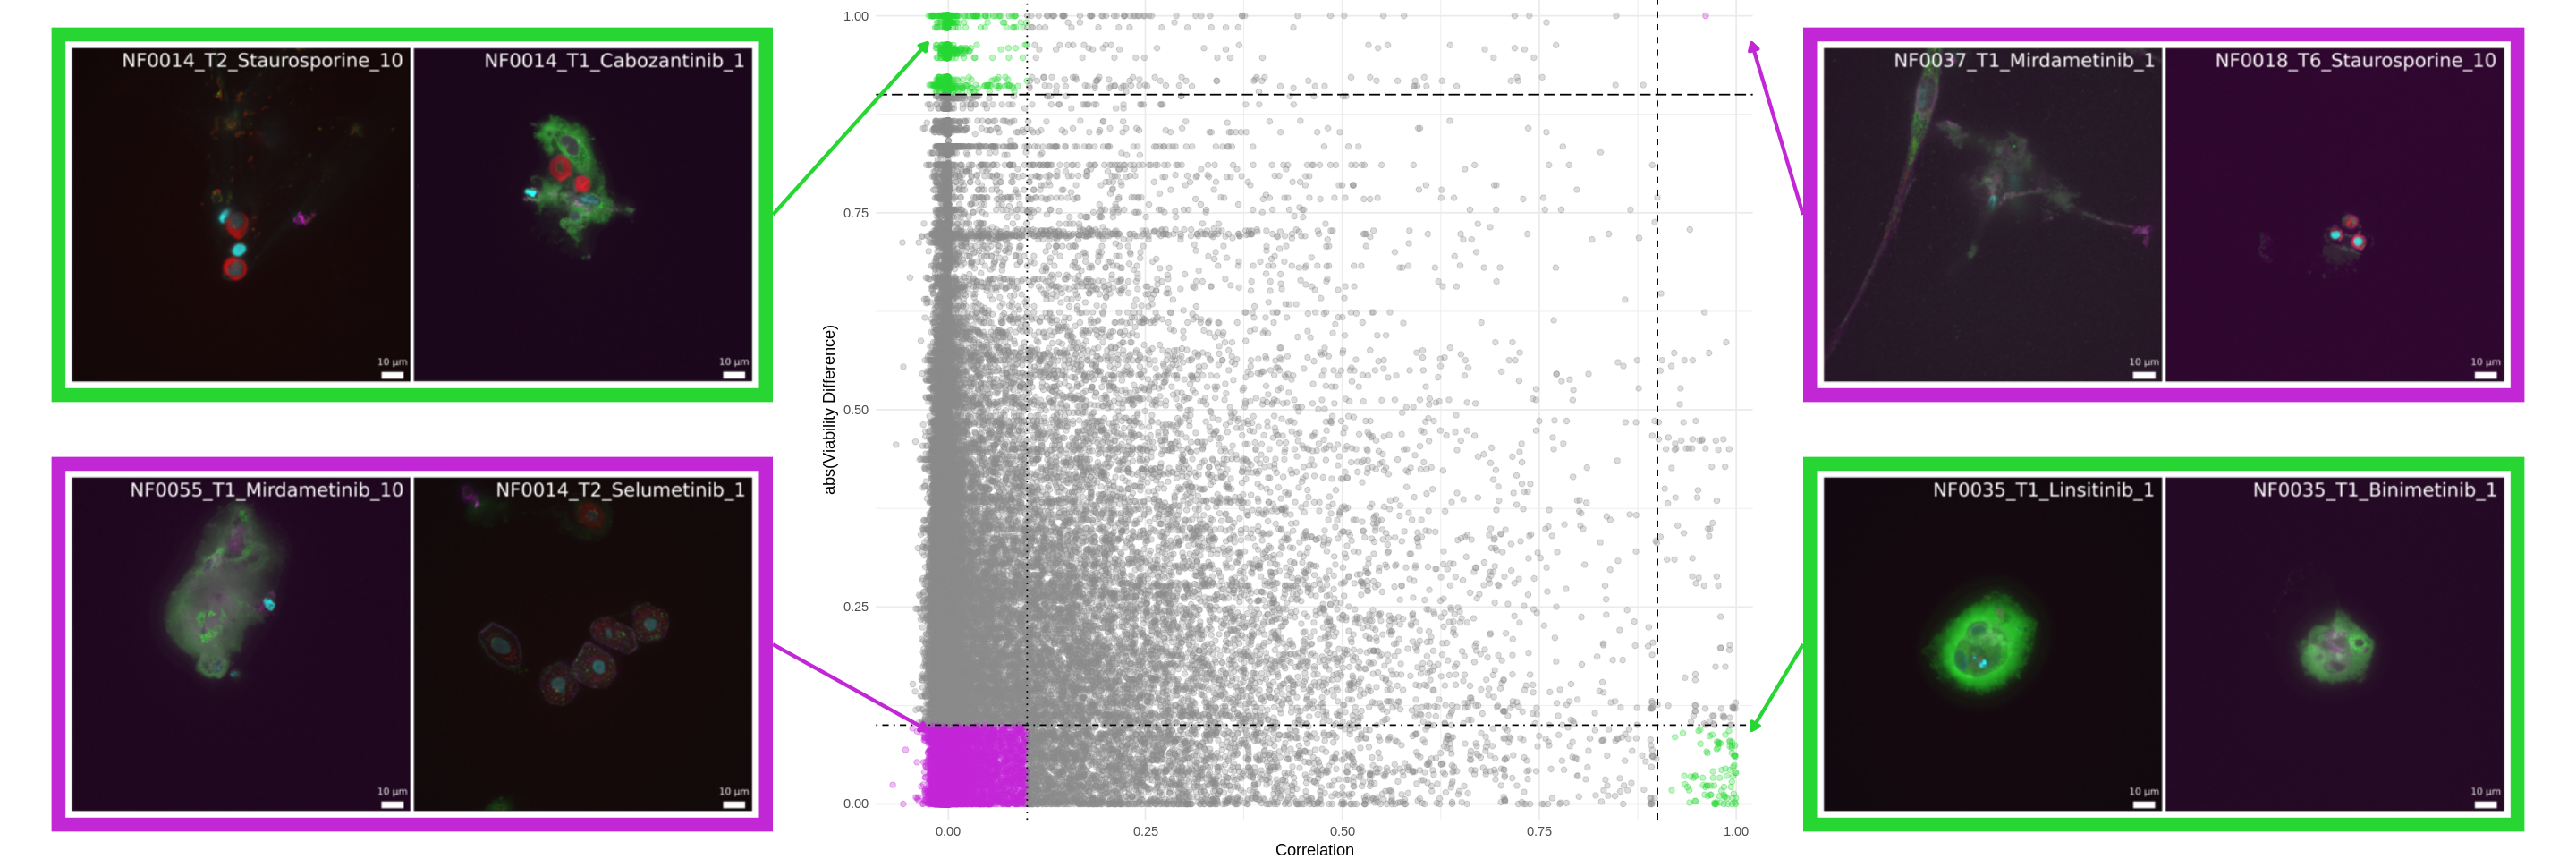

In [5]:
height <- 8
width <- 24
options(repr.plot.width = width, repr.plot.height = height)

img_paths <- list(
  top_left     = file.path(root_dir, "1.EDA/figures/montages/low_correlation_dissimilar_viability/NF0014_T2__C2__Staurosporine__10__NF0014_T1__E7__Cabozantinib__1.png"),
  top_right    = file.path(root_dir, "1.EDA/figures/montages/high_correlation_dissimilar_viability/NF0037_T1__E8__Mirdametinib__1__NF0018_T6__G2__Staurosporine__10.png"),
  bottom_left  = file.path(root_dir, "1.EDA/figures/montages/low_correlation_similar_viability/NF0055_T1__G8__Mirdametinib__10__NF0014_T2__D11__Selumetinib__1.png"),
  bottom_right = file.path(root_dir, "1.EDA/figures/montages/high_correlation_similar_viability/NF0035_T1__G3__Linsitinib__1__NF0035_T1__F7__Binimetinib__1.png")
)

# same palette used to color the scatterplot quadrants
quadrant_palette <- c(
  "top_left" = "#27d633",
  "top_right" = "#c227d6",
  "bottom_left" = "#c227d6",
  "bottom_right" = "#27d633",
  "middle" = "#8b8b8b"
)

# resize to fill the box, then add a colored border matching the quadrant
target_px <- "600x300!"
border_px <- "12x12"  # thickness of the colored outline

imgs <- lapply(names(img_paths), function(q) {
  img <- image_resize(image_read(img_paths[[q]]), target_px)
  image_border(img, color = quadrant_palette[[q]], geometry = border_px)
})
names(imgs) <- names(img_paths)

p_base <- correlation_viability_plot +
  scale_x_continuous(expand = expansion(mult = 0.02)) +
  scale_y_continuous(expand = expansion(mult = 0.02)) +
  theme(
    plot.margin = margin(0, 0, 0, 0),
    plot.background = element_rect(fill = "white", color = NA)
  )

canvas <- ggdraw() +
  draw_plot(p_base, x = 0.30, y = 0, width = 0.40, height = 1) +

  draw_image(imgs$top_left,     x = 0.02, y = 0.5, width = 0.28, height = 0.5) +
  draw_image(imgs$bottom_left,  x = 0.02, y = 0,   width = 0.28, height = 0.5) +
  draw_image(imgs$top_right,    x = 0.70, y = 0.5, width = 0.28, height = 0.5) +
  draw_image(imgs$bottom_right, x = 0.70, y = 0,   width = 0.28, height = 0.5) +

  # colored arrows from each image toward the region of the plot it represents,
  # matching the border/quadrant color so the source is unambiguous
  draw_line(x = c(0.30, 0.36), y = c(0.75, 0.95),
            color = quadrant_palette[["top_left"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.30, 0.36), y = c(0.25, 0.15),
            color = quadrant_palette[["bottom_left"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.70, 0.68), y = c(0.75, 0.95),
            color = quadrant_palette[["top_right"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.70, 0.68), y = c(0.25, 0.15),
            color = quadrant_palette[["bottom_right"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed"))

ggsave(
  filename = file.path(figures_base_dir, "correlation_vs_viability_with_examples.png"),
  plot = canvas,
  width = width,
  height = height,
  dpi = 600,
  bg = "white"
)
canvas